
Raw Images


Validation — check image files


Preprocessing — resize and normalize


Augmentation — create training variations


Dataset → DataLoader → Model

### Simple Concept

A folder-based dataset is a collection of images organized into folders. Each folder represents a class, or category, that the model needs to recognize.

For example, suppose we want to build a CNN that classifies cats and dogs.

The images can be stored like this:

```text
image_dataset/
├── cat/
│   ├── cat1.jpg
│   ├── cat2.jpg
│   └── cat3.jpg
└── dog/
    ├── dog1.jpg
    ├── dog2.jpg
    └── dog3.jpg
```

Here:
- `cat` contains cat images.
- `dog` contains dog images.
- Each image is a training example.
- The folder name tells us the correct class of each image.

**Why is this needed?**

Organizing images into folders makes it easier to load thousands of images, assign their labels, and train a CNN without manually labeling every image in Python.

**Real-world example**

A medical image dataset might contain `Normal` and `Pneumonia` folders. The folder names identify the categories used for image classification, assuming the dataset has been correctly labeled.

**Important:** Folder-based organization does not automatically guarantee that the labels are correct. The images and their assigned folders should still be checked.

In [1]:

from pathlib import Path

dataset_path = Path("image_dataset")

# Create class folders
(dataset_path / "cat").mkdir(parents=True, exist_ok=True)
(dataset_path / "dog").mkdir(parents=True, exist_ok=True)

# Display the folder structure
for class_folder in dataset_path.iterdir():
    if class_folder.is_dir():
        print("Class:", class_folder.name)
        print("Images:", len(list(class_folder.iterdir())))


Class: cat
Images: 0
Class: dog
Images: 0


### Simple Concept

Class mapping is the process of converting class names into numerical labels.

A CNN works with numerical data, so we assign a number to each image category.

For example:

- `cat` → `0`
- `dog` → `1`
- `horse` → `2`

This is called **class mapping**.

### Why is it needed?

When training an image classification model, each image needs a corresponding label. Class mapping converts readable category names into numerical labels that can be used during training.

### Real-world example

Suppose a dataset contains images of cars, bikes, and buses.

The class mapping could be:

- `bike` → `0`
- `bus` → `1`
- `car` → `2`

The model learns to predict the numerical class for each image.

**Important:** The exact numbers assigned to classes are not inherently meaningful. The same mapping must be used consistently during training, validation, testing, and prediction.

In [2]:

from pathlib import Path

dataset_path = Path("image_dataset")

# Get class names from folders
class_names = sorted(
    folder.name
    for folder in dataset_path.iterdir()
    if folder.is_dir()
)

# Create class mapping
class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Class names:", class_names)
print("Class mapping:", class_to_index)


Class names: ['cat', 'dog']
Class mapping: {'cat': 0, 'dog': 1}


Python explanation
- Path("image_dataset") identifies your dataset folder.
- iterdir() lists the items inside that folder.
- is_dir() selects only folders.
- sorted() arranges the class names alphabetically.
- enumerate() assigns an index to each class, starting from 0.
- class_to_index stores each class name and its numerical label.
Remember: If the folders are empty, the class mapping still works because it reads the folder names, not the images.

In [3]:

from pathlib import Path

dataset_path = Path("image_dataset")

splits = ["train", "val", "test"]
classes = ["cat", "dog"]

for split in splits:
    for class_name in classes:
        folder = dataset_path / split / class_name
        folder.mkdir(parents=True, exist_ok=True)

print("Dataset directory structure created.")


Dataset directory structure created.


### Simple Concept

Image validation means checking whether images are suitable for use in a computer vision dataset before training a CNN.

Not every image file is suitable for training. Some images may have unexpected formats, very small dimensions, or incorrect file extensions.

### What should we check?

- **File format:** Is the image in an accepted format, such as JPG, JPEG, or PNG?
- **Image dimensions:** Is the image large enough for the task?
- **Image readability:** Can Python open and read the image?
- **File existence:** Does the expected image file actually exist?

### Why is it needed?

Image validation helps identify unsuitable files before training begins. This reduces data-loading errors and helps maintain dataset quality.

### Real-world example

Suppose a dataset contains 500 animal images. Some images are extremely small, and one file cannot be opened. Validating the dataset helps identify these issues before they interrupt model training.

**Important:** Image validation checks file quality and suitability. It does not guarantee that the image has the correct class label or that the image itself is meaningful.

In [4]:

from pathlib import Path
from PIL import Image

image_folder = Path("image_dataset/train/cat")

valid_extensions = {".jpg", ".jpeg", ".png"}
minimum_width = 32
minimum_height = 32

for image_path in image_folder.iterdir():

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in valid_extensions:
        print(image_path.name, "- Unsupported format")
        continue

    try:
        with Image.open(image_path) as image:
            width, height = image.size

            if width < minimum_width or height < minimum_height:
                print(image_path.name, "- Image too small")
            else:
                print(image_path.name, "- Valid image",
                      image.size)

    except (OSError, ValueError):
        print(image_path.name, "- Cannot read image")


Python explanation
- Path() specifies the folder containing your images.
- valid_extensions lists the accepted file extensions.
- image_path.suffix.lower() checks the extension without case sensitivity.
- Image.open() attempts to open the image.
- image.size returns its width and height.
- The try-except block handles common image-reading errors.
- Images smaller than 32 × 32 pixels are flagged according to our chosen rule.
Note: The 32 × 32 minimum is an example, not a universal requirement. Choose suitable dimensions for your project. This check also does not guarantee that every image is visually correct.

### Simple Concept

A corrupted image is a file that cannot be read or decoded properly as an image.

This can happen when a file is incomplete, damaged, or saved in an invalid format.

A file may have a `.jpg` extension but still contain invalid image data.

### Why is it needed?

During CNN training, corrupted images can cause errors when the DataLoader tries to load a batch.

Detecting these files before training helps prevent interruptions.

### Real-world example

Suppose you have 2,000 images for an animal classification project. If one image is corrupted, the training process might fail when it reaches that file.

We can scan the dataset, identify unreadable images, and decide whether to repair or remove them.

**Important:** Do not automatically delete files during validation. First identify the problematic files and review them before taking action.

In [5]:

from pathlib import Path
from PIL import Image

dataset_path = Path("image_dataset/train")

valid_extensions = {".jpg", ".jpeg", ".png"}
corrupted_images = []

for image_path in dataset_path.rglob("*"):

    if not image_path.is_file():
        continue

    if image_path.suffix.lower() not in valid_extensions:
        continue

    try:
        with Image.open(image_path) as image:
            image.verify()

    except (OSError, ValueError, SyntaxError):
        corrupted_images.append(str(image_path))

print("Corrupted images:", len(corrupted_images))

for image_path in corrupted_images:
    print(image_path)


Corrupted images: 0


Python explanation
- rglob("*") searches for files in the training folder and its subfolders.
- Image.open() attempts to read each image.
- image.verify() checks whether the image file appears structurally valid.
- try-except catches common decoding and file errors.
- corrupted_images stores the paths of files that fail the check.
Important: verify() checks file integrity, but it does not guarantee that every image can be fully decoded or that its contents are visually correct. For stricter validation, reopen the image and call load().
Expected output when all images are valid:

### Simple Concept

Class imbalance occurs when some classes in a dataset contain significantly more images than other classes.

For example, consider an animal classification dataset:

- Cat: 900 images
- Dog: 100 images

The dataset contains many more cat images than dog images. This is called **class imbalance**.

### Why is it needed?

A CNN trained on an imbalanced dataset may perform well on the majority class but poorly on the minority class.

For example, the model might predict cats correctly most of the time but struggle to recognize dogs.

Therefore, we should examine the number of images in each class before training.

### Real-world example

Suppose a medical image dataset contains:
- Normal: 950 images
- Disease: 50 images

A model could achieve high accuracy by predicting `Normal` for most images, while failing to identify many disease cases.

Accuracy alone may hide this problem.

### How can we handle class imbalance?

- Collect more images for underrepresented classes when possible.
- Apply suitable data augmentation to the training images of minority classes.
- Use class-weighted loss when appropriate.
- Evaluate precision, recall, and F1-score in addition to accuracy.

**Important:** Do not rebalance the validation or test sets just to improve the reported results. Keep evaluation data representative of the intended real-world use.

Images per class:
cat : 0
dog : 0


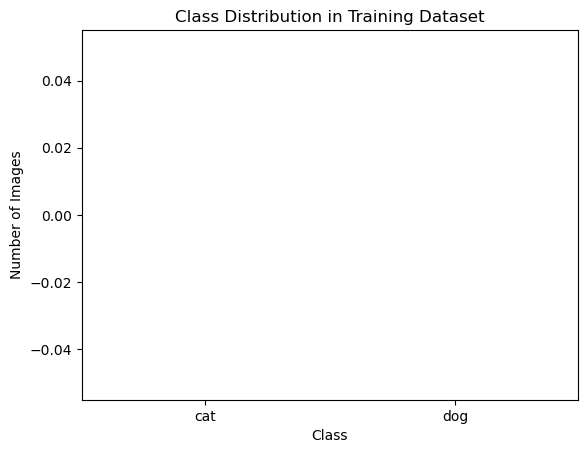

In [6]:

from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

dataset_path = Path("image_dataset/train")

valid_extensions = {".jpg", ".jpeg", ".png"}

class_counts = Counter()

for class_folder in dataset_path.iterdir():

    if not class_folder.is_dir():
        continue

    count = sum(
        1 for image_path in class_folder.rglob("*")
        if image_path.is_file()
        and image_path.suffix.lower() in valid_extensions
    )

    class_counts[class_folder.name] = count

print("Images per class:")

for class_name, count in class_counts.items():
    print(class_name, ":", count)

plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Training Dataset")
plt.show()


Python explanation
- Counter() stores the image count for each class.
- iterdir() finds the class folders.
- rglob("*") searches for image files inside each class folder.
- sum() counts the matching files.
- plt.bar() creates a bar chart so you can compare class sizes visually

### Simple Concept

Dataset statistics means collecting useful information about an image dataset to understand its size, quality, and distribution.

Before training a CNN, we should understand what data we have.

### What should we measure?

- **Total images:** How many images are available?
- **Images per class:** How many images belong to each category?
- **Image dimensions:** What are the width and height of the images?
- **Image formats:** Are the images JPG, JPEG, or PNG?
- **Corrupted images:** How many files cannot be read?
- **Class distribution:** Are the classes balanced or imbalanced?

### Why is it needed?

Dataset statistics help us identify missing data, class imbalance, inconsistent image sizes, and potential data-quality problems before model training.

They also help us decide whether preprocessing or additional data collection is required.

### Real-world example

Suppose you are building a CNN to classify cats and dogs. Your dataset contains 1,000 images, but 900 belong to cats and only 100 belong to dogs.

Dataset statistics reveal this imbalance before training begins.

**Important:** Dataset statistics should be calculated separately for training, validation, and test datasets when appropriate. Use the training data to fit preprocessing steps such as normalization statistics, rather than using information from the test set.

In [7]:

from pathlib import Path
from collections import Counter
from PIL import Image

dataset_path = Path("image_dataset/train")

valid_extensions = {".jpg", ".jpeg", ".png"}

class_counts = Counter()
format_counts = Counter()
dimension_counts = Counter()

total_images = 0
unreadable_images = 0

for class_folder in dataset_path.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.rglob("*"):

        if not image_path.is_file():
            continue

        if image_path.suffix.lower() not in valid_extensions:
            continue

        total_images += 1
        class_counts[class_folder.name] += 1
        format_counts[image_path.suffix.lower()] += 1

        try:
            with Image.open(image_path) as image:
                image.load()
                dimension_counts[image.size] += 1

        except (OSError, ValueError, SyntaxError):
            unreadable_images += 1

print("Total images:", total_images)
print("Images per class:", dict(class_counts))
print("File formats:", dict(format_counts))
print("Image dimensions:", dict(dimension_counts))
print("Unreadable images:", unreadable_images)


Total images: 0
Images per class: {}
File formats: {}
Image dimensions: {}
Unreadable images: 0


Python explanation
- total_images counts supported image files.
- class_counts tracks how many images belong to each class.
- format_counts counts image file extensions.
- dimension_counts records the image dimensions, such as (224, 224).
- image.load() attempts to decode the image data.
- unreadable_images counts files that fail to load.